# STAT 207 Project 03 - Generational Wealth Among Billionaires



<hr>

## 1. Introduction

## Generational Wealth Among Billionaires

**Data Introduction:** In billionaires.csv, researchers compiled a datatset of the super-rich from the Forbes World’s Billionaires lists from 1996-2014. Scholars at Peterson Institute for International Economics have added a couple dozen more variables about each billionaire.


**Research Question:**

Section 2: Linear Regression
* What is the relationship between the amount in a billionaire's wealth and their age (as of 2014) after controlling for gender, if they inherited their wealth, and the the type of company there were involved in?
* How does my model perform on new data?

Section 3: Logistical Regression
- How do gender, age, and networth relate to the log-odds of an individual being in the inherited wealth group in the training data?
- How does the classifer based on this model perform on new data?


**Response Variables:**
Describe what your two response variables will be for your 
two research questions, respectively.

* What is the predicted amount of wealth for billionaires based on their age?
* What is the log odds of a billionaire's wealth being inherited?


**Contextual Importance:**
Money has become a necessity for life. Most individuals wished they had more money to their name and like to joke about striking it rich one day. Other people purposely work through their careers and crawl up the ladder for weathly. From the model created in this project, we want to judge if becoming insanely wealth (billionaire) is attainable? If most billionaires are self-made that provides optimism to a merit-based system. Otherwise, inheritence of wealth would signal that rich rich life more of a lucky fantasy. This analysis is best used as entertainment for those climbing the corporate ladder and trying to see if the very top is reachable.

In [1]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.formula.api as smf

After finding looking through the data, I noticed that na_values were listed as nan, so I dropped them. The dataset originally has 2614 entries and that decreased to 2539 entries (75 or -2.87% less) after dropping nan values. Since this is relatively small, I believe it would be insignificant to the analysis of our fitted regression models.

Additionally, I found that some entries for demographic.gender was inputted as "married couple" when it was married couple that shared the wealth. Since only 3 rows were married couples, I thought it would be better to focus on only single individuals.

Lastly, I noticed the same billionaires listed mutiple times here. Since I want to explore characteristics of billionaires, I believed it wouldn't be representative if a specific billionaire's trait was more heavily weight just because they appeared more often in the dataset. Therefore, I removed duplicate appearances to include only the most last entry based on "year".

In the end, the cleaned dataset had 2004 entries.

In [2]:
df = pd.read_csv("billionaires.csv", na_values = ["nan", "married couple"])
df = df.dropna()
df = df.sort_values(by="year", ascending=False)
df = df.drop_duplicates(subset="name", keep="first").reset_index()
df

,index,name,rank,year,company.founded,company.name,company.relationship,company.sector,company.type,demographics.age,...,location.gdp,location.region,wealth.type,wealth.worth in billions,wealth.how.category,wealth.how.from emerging,wealth.how.industry,wealth.how.inherited,wealth.how.was founder,wealth.how.was political
0,2613,Zhu Wenchen,1565,2014,1999,Furen Pharmaceutical Group,chairman,pharmaceuticals,new,48,...,0.000000e+00,East Asia,executive,1.0,New Sectors,True,Technology-Medical,not inherited,True,True
1,2612,Zdenek Bakala,1565,2014,1994,Patria Finance,founder,coal,new,53,...,0.000000e+00,Europe,privatized and resources,1.0,Resource Related,True,Mining and metals,not inherited,True,True
2,2611,Yang Keng,1565,2014,0,Blue Ray Corp,chairman,real estate,new,53,...,0.000000e+00,East Asia,self-made finance,1.0,Financial,True,Real Estate,not inherited,True,True
3,2,Bill Gates,1,2014,1975,Microsoft,founder,Software,new,58,...,0.000000e+00,North America,founder non-finance,76.0,New Sectors,True,Technology-Computer,not inherited,True,True
4,2610,Wu Xiong,1565,2014,1999,Biostime International Holdings,owner,infant formula,new,0,...,0.000000e+00,East Asia,executive,1.0,Traded Sectors,True,Consumer,not inherited,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999,60,Gerard Mulliez,21,1996,1961,Auchan,founder,retail,new,0,...,1.610000e+12,Europe,founder non-finance,5.7,Non-Traded Sectors,True,"Retail, Restaurant",not inherited,True,True
2000,1227,Abdul Aziz Al-Sulaiman,404,1996,1968,Rolaco Trading and Contracting Company,founder,construction,new,0,...,1.580000e+11,Middle East/North Africa,self-made finance,1.0,Financial,True,Money Management,not inherited,True,True
2001,1225,Eugenio Lopez,402,1996,1961,Jumex,owner,drinks,new,0,...,8.284819e+10,East Asia,self-made finance,1.0,Financial,True,Diversified financial,not inherited,True,True
2002,587,John Gokongwei,196,1996,1957,JG Summit Holdings,founder,manufacturing,new,0,...,8.284819e+10,East Asia,self-made finance,2.0,Financial,True,Diversified financial,not inherited,True,True


In [3]:
df["demographics.gender"].unique()
df[df["demographics.gender"] == "married couple"]
len(df[df["demographics.gender"] == "married couple"])

0

Here, I noticed that "new" in the company.type column had mutiple variations, that being " new", "new ", and "neew." I cleaned this up and replace both as "new."

Moreover, in the company.type column, "acquired" was mispelled as "aquired" and " acquired"

In [4]:
df["company.type"].unique()

array(['new', 'subsidiary', ' new', ' acquired', 'acquired',
       'privatization', 'aquired', 'state owned enterprise',
       'new division', 'merger', 'new/aquired', 'new ',
       'new, privitization', 'joint venture', 'franchise rights', 'neew',
       'franchise', 'privatized'], dtype=object)

In [5]:
df["company.type"] = df["company.type"].str.replace(" new", "new")
df["company.type"] = df["company.type"].str.replace("neew", "new")
df["company.type"] = df["company.type"].str.replace("new ", "new")

df["company.type"] = df["company.type"].str.replace("aquired", "acquired")
df["company.type"] = df["company.type"].str.replace(" acquired", "acquired")
df["company.type"].unique()

array(['new', 'subsidiary', 'acquired', 'privatization',
       'state owned enterprise', 'newdivision', 'merger', 'new/acquired',
       'new, privitization', 'joint venture', 'franchise rights',
       'franchise', 'privatized'], dtype=object)

Later on, a logistical regression model will be fitted using the "wealth.how.inherited" column to predict if a billionaire's wealth was inherited or not. Below, I made the "wealth.how.inherited" in the logical response variable called "inherited?" by distinguishing their wealth as "not inherited" if it was "not inherited" and all other inputs as "inherited."

In [6]:
df["wealth.how.inherited"].unique()

array(['not inherited', 'father', 'spouse/widow', '3rd generation',
       '4th generation', '5th generation or longer'], dtype=object)

In [7]:
df["wealth.how.inherited"] = df["wealth.how.inherited"].replace({"3rd generation": "inherited", 
                                                                 "father": "inherited", 
                                                                 "spouse/widow": "inherited",
                                                                 "5th generation or longer": "inherited",
                                                                 "4th generation": "inherited"})

df["inheritence"] = (df["wealth.how.inherited"] == "inherited") * 1

Then, I filtered the dataframe for only columns that we will be using to fit our model.

In [8]:
df = df[["name", "company.name", "demographics.age", "demographics.gender","wealth.worth in billions", "inheritence", "company.founded", "company.relationship", "company.sector", "company.type"]]
df

,name,company.name,demographics.age,demographics.gender,wealth.worth in billions,inheritence,company.founded,company.relationship,company.sector,company.type
0,Zhu Wenchen,Furen Pharmaceutical Group,48,male,1.0,0,1999,chairman,pharmaceuticals,new
1,Zdenek Bakala,Patria Finance,53,male,1.0,0,1994,founder,coal,new
2,Yang Keng,Blue Ray Corp,53,male,1.0,0,0,chairman,real estate,new
3,Bill Gates,Microsoft,58,male,76.0,0,1975,founder,Software,new
4,Wu Xiong,Biostime International Holdings,0,male,1.0,0,1999,owner,infant formula,new
...,...,...,...,...,...,...,...,...,...,...
1999,Gerard Mulliez,Auchan,0,male,5.7,0,1961,founder,retail,new
2000,Abdul Aziz Al-Sulaiman,Rolaco Trading and Contracting Company,0,male,1.0,0,1968,founder,construction,new
2001,Eugenio Lopez,Jumex,0,male,1.0,0,1961,owner,drinks,new
2002,John Gokongwei,JG Summit Holdings,0,male,2.0,0,1957,founder,manufacturing,new


Finally, I didn't want to worry about syntax when fitted my model so, I renamed the columns.

In [9]:
df = df.rename(columns={
    "demographics.age":"age",
    "demographics.gender":"gender", 
    "wealth.worth in billions":"networth",
    "company.founded":"year_company_founded", 
    "company.relationship":"company_relationship", 
    "company.sector":"company_sector", 
    "company.type":"company_type"})

df

,name,company.name,age,gender,networth,inheritence,year_company_founded,company_relationship,company_sector,company_type
0,Zhu Wenchen,Furen Pharmaceutical Group,48,male,1.0,0,1999,chairman,pharmaceuticals,new
1,Zdenek Bakala,Patria Finance,53,male,1.0,0,1994,founder,coal,new
2,Yang Keng,Blue Ray Corp,53,male,1.0,0,0,chairman,real estate,new
3,Bill Gates,Microsoft,58,male,76.0,0,1975,founder,Software,new
4,Wu Xiong,Biostime International Holdings,0,male,1.0,0,1999,owner,infant formula,new
...,...,...,...,...,...,...,...,...,...,...
1999,Gerard Mulliez,Auchan,0,male,5.7,0,1961,founder,retail,new
2000,Abdul Aziz Al-Sulaiman,Rolaco Trading and Contracting Company,0,male,1.0,0,1968,founder,construction,new
2001,Eugenio Lopez,Jumex,0,male,1.0,0,1961,owner,drinks,new
2002,John Gokongwei,JG Summit Holdings,0,male,2.0,0,1957,founder,manufacturing,new


## 2. Linear Regression Analytical Tasks

**Research Question:**

* What is the relationship between the amount in a billionaire's wealth and their age (as of 2014) after controlling for gender, if they inherited their wealth, and the the type of company there were involved in?
* How does my model perform on new data?

In [10]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size = 0.3, random_state = 32)
df_train

,name,company.name,age,gender,networth,inheritence,year_company_founded,company_relationship,company_sector,company_type
1848,Wang Yue-che,Formosa Plastics,84,male,2.7,0,1954,founder,petrochemicals,new
534,Augusto & Giorgio Perfetti,Perfetti Van Melle,0,male,7.2,1,1946,relation,candy,new
822,Rosely Schweizer,Oetker-Gruppe,73,female,1.7,1,1891,relation,retail,new
426,Sun Pingfan,Ningbo Cixing,44,male,1.3,0,2003,chairman,sewing machines,new
1636,Carlos Slim Helu,Telmex,74,male,72.0,0,1990,founder,Communications,privatization
...,...,...,...,...,...,...,...,...,...,...
892,Shin Dong-Joo,Lotte Group,60,male,1.8,1,1948,relation,retail,new
1334,Renate Reimann-Haas,Benckiser,62,female,3.3,1,1923,relation,consumer goods,acquired
1925,Bernardo Garza Sada,Grupo ALFA,0,male,1.5,1,1890,relation,aluminum,new
1579,Yasumitsu Shigeta,Hikari Tsushin,49,male,2.6,0,1988,founder,mobile phones,new


In [11]:
linear = smf.ols("networth ~ age + gender + inheritence + company_type", data=df_train).fit()
linear.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               networth   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.810
Date:                Mon, 25 May 2026   Prob (F-statistic):            0.00124
Time:                        15:57:05   Log-Likelihood:                -4362.5
No. Observations:                1402   AIC:                             8749.
Df Residuals:                    1390   BIC:                             8812.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
Intercept                                  1.9839      0.805      2.465      0.014       0.405       3.563
gender[T.male]                             0.0746      0.505      0.148      0.883      -0.916       1.065
company_type[T.franchise rights]          -0.2218      5.484     -0.040      0.968     -10.980      10.536
company_type[T.merger]                     1.4154      3.897      0.363      0.717      -6.229       9.060
company_type[T.new]                       -0.1793      0.548     -0.327      0.743      -1.254       0.895
company_type[T.new, privitization]         0.1968      5.484      0.036      0.971     -10.561      10.954
company_type[T.new/acquired]               2.5902      5.485      0.472      0.637      -8.170      13.350
company_type[T.privatization]              2.1210      1.216      1.744      0.081      -0.265       4.507
company_type[T.state owned enterprise]     0.3358      2.796      0.120      0.904      -5.149       5.821
company_type[T.subsidiary]                -2.2976      2.499     -0.919      0.358      -7.200       2.605
age                                        0.0281      0.006      4.670      0.000       0.016       0.040
inheritence                                0.6879      0.330      2.087      0.037       0.041       1.334
==============================================================================
Omnibus:                     1683.130   Durbin-Watson:                   2.021
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           200283.621
Skew:                           6.172   Prob(JB):                         0.00
Kurtosis:                      60.238   Cond. No.                     2.32e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.32e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Linear Regression Equation:**

This equation is going to be for predicting networth in $billions for billionaries that were associated with a company that was newly found as the company_type[T.] variable has a large number of levels.

$\widehat{y}$ = 2.4599 + 0.0259(age) + 0.0362(male) - 0.4571(company_type_new) + 0.6427(inheritence)

**Examining relationship between predicted billionaires networth and their age:**

Slope coefficient interpretation: 

For each additional 1 year increase in age of a billionaire that was associated with a new company, the predicted expected networth in $billions increases by ~0.0259, holding gender, company type, and whether they inherited their wealth constant.

95% confidence interval: 

The 95% confidence interval for the slope is (0.016, 0.040). Since 0 is not within this interval, we can conclude that the population slope is positive at 95% confidence, indicating a significant positive relationship between age and networth.

**Graphical/numerical summaries to check the linear regression conditions:**


Do these summaries support that the conditions are met and that your answers for the two questions above (descriptive analytics and inference) are valid?
2-3

First, I created a fitted vs. residual plot to test linearity of x and y's relationship (age and networth). The residual plot does not support the linearity assumption because the points are not randomly scattered Instead, there are a lot of large positive residuals and the uneven clustering suggests the model did not perform well in capture the distritbuion in net worth. Additionally, The equal‑variance assumption is also not met, as the spread of residuals changes across fitted values rather than remain constant. 

Overall, the plot indicates violations of both assumptions. Since linearity of x and y is required for a linear regression model to be valid, the answers to my two questions above will not be valid.

Even so, I generated two more visualization to check more conditions.

Text(0.5, 1.0, 'Fitted vs. Residual Plot')

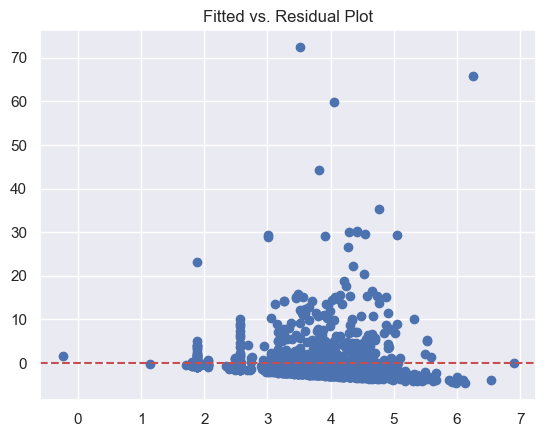

In [12]:
plt.scatter(linear.predict(df_train), df_train["networth"] - linear.predict(df_train))
plt.axhline(y=0, color="r", linestyle="--")
plt.title("Fitted vs. Residual Plot")

Next, I also generated a small correlation matrix of all the quantitative variable to check for potential multicollineraity. There seems to be no multicollinearity between age and networth as 0.114732 is relatively weak.

In [13]:
df_train[["networth", "age"]].corr()

,networth,age
networth,1.000000,0.123098
age,0.123098,1.000000


Finally, I generated a QQplot to check for normality. The distribution of residuals in not normal.

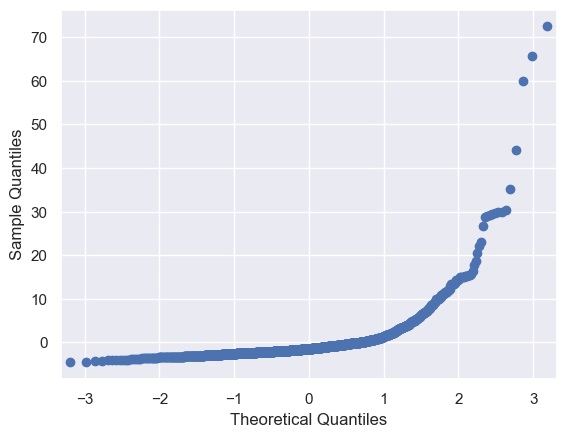

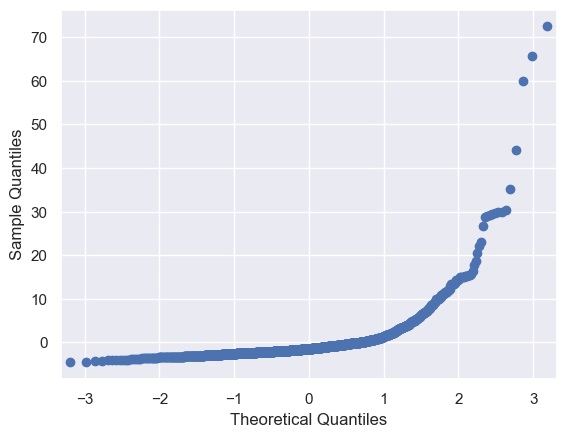

In [14]:
import statsmodels.api as sm
sm.qqplot(linear.resid)

**Evaluating model performance**

$R^2$ ≈ 0.022

~2.2% percent of variability in predicted networth is explained by the linear regression model in the training data. This very low value indicates that our linear model did not perform well to predict billionaires' networth. This was expected as our linearity assumption was not even fufilled.

RMSE = 5.045895711411772

Roughly, an obeserved networth of a billionaire falls from its predicted expected value by about $5.5099 billion. This is an extremely high amount of error as it is over 2 times out IQR = 1.9 = 3.3-1.4 = 1.9.

While calculating the RMSE, I got an error due to the company_type column in df_test. There is only one billionaire who is mainly involved in a frahcnise company, one in a privatized company, and one in a joint venutre company. Therefore, there are extra unique variables that is in df_test but not df_train. This prevents me from generating a RMSE, so I am going to remove these row. This will be insignificant to the accuracy of the RMSE as it is only 3 out of 602 rows of data removed.

In [15]:
len(df[df["company_type"] == "franchise"])
len(df_test[df_test["company_type"] == "franchise"])
df_test = df_test[df_test["company_type"] != "franchise"]

len(df_test[df_test["company_type"] == "privatized"])
df_test = df_test[df_test["company_type"] != "privatized"]

df_test = df_test[df_test["company_type"] != "newdivision"]

df_test = df_test[df_test["company_type"] != "joint venture"]

In [16]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(df_test["networth"], linear.predict(df_test))
rmse

5.045895711411772

In [17]:
df_test[["networth"]].describe()

,networth
count,598.000000
mean,3.496321
std,5.071484
min,1.000000
25%,1.400000
50%,2.000000
75%,3.300000
max,58.200000


{'whiskers': [<matplotlib.lines.Line2D at 0x2404ebc1810>,
 'caps': [<matplotlib.lines.Line2D at 0x2404ebc1a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x2404ebc16d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2404ebc1d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x2404ebc1e50>],
 'means': []}

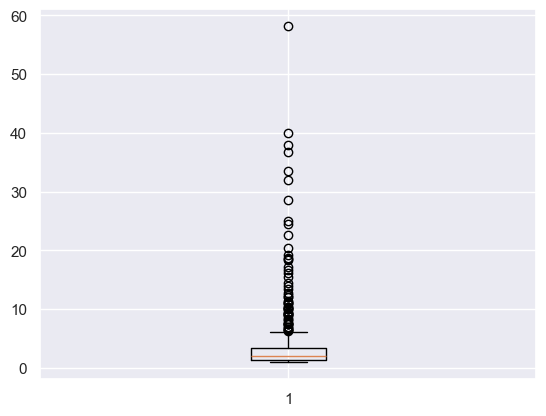

In [18]:
plt.boxplot(df_test["networth"])

## 3. Logistic Regression Analytical Tasks

**Research Question**

- How do gender, age, and networth relate to the log-odds of an individual being in the inherited wealth group in the training data?
- How does the classifer based on this model perform on new data?

In [19]:
log_mod = smf.logit(formula= "inheritence ~ gender + age + networth", data = df_train).fit()
log_mod.summary()

Optimization terminated successfully.
         Current function value: 0.583088
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            inheritence   No. Observations:                 1402
Model:                          Logit   Df Residuals:                     1398
Method:                           MLE   Df Model:                            3
Date:                Mon, 25 May 2026   Pseudo R-squ.:                 0.08154
Time:                        15:57:07   Log-Likelihood:                -817.49
converged:                       True   LL-Null:                       -890.06
Covariance Type:            nonrobust   LLR p-value:                 2.931e-31
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.3996      0.243      5.749      0.000       0.922       1.877
gender[T.male]    -2.2224      0.210    -10.584      0.000      -2.634      -1.811
age               -0.0036      0.002     -1.476      0.140      -0.008       0.001
networth           0.0190      0.010      1.831      0.067      -0.001       0.039
==================================================================================
"""

**Fit Logistic Regression Model**


Gender: Gender (male) has coefficient of -2.2224. This indicates that male have a lower probablilty of inheritence comapred to females, holding other variables constant.

Age: Age has a coefficient of -0.0036. This indicates that higher age is associated with lower probability of inheritence comapred to younger age, holding other variables constant. However, since this value is very small, the effect is probability not significant.

Networth: The coefficient of networth is 0.0190. This indicates that individuals with higher networth tend to have a higher probability of inheriting their wealth, compared to an individual with lower networth, holding other variables constant.

Model Strength -
Pseudo-R^2 Interpretation: The pseudo-R^2 for our model is 0.08154, which indicates that the model explains about 8% of the variation in the log-odds of inheritence. This suggests that, while the gender, age, and networth have some relationship with inheritence, the overall strength of the model is fairly weak.

In [20]:
df_train["predictive_prob"] = log_mod.predict(df_train)
df_train[["predictive_prob", "inheritence"]].head()

,predictive_prob,inheritence
1848,0.254445,0
534,0.334934,1
822,0.762804,1
426,0.277453,0
1636,0.569269,0


In [21]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_true = df_train["inheritence"], y_score = df_train["predictive_prob"])
auc

0.6381550529372839

AUC Interpretation: The AUC for our model is 0.638, which indicates a moderate strength of the model. This means that it has a moderate predictive probability perfromance to distinguish whether an individual billionaire inherited their wealth or not.

**Building and Evaluating a Classifer**

In [22]:
df_train["y_hat"] = 1 * (df_train["predictive_prob"] >= 0.5)
df_train[["inheritence", "y_hat", "predictive_prob"]].head()


,inheritence,y_hat,predictive_prob
1848,0,0,0.254445
534,1,0,0.334934
822,1,1,0.762804
426,0,0,0.277453
1636,0,1,0.569269


In [23]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true = df_train["inheritence"], y_pred = df_train["y_hat"])
tn,fp,fn,tp = confusion_matrix(y_true = df_train["inheritence"], y_pred = df_train["y_hat"]).ravel()
(tn,fp,fn,tp)

(np.int64(903), np.int64(35), np.int64(350), np.int64(114))

In [24]:
accuracy = (tn + tp)/(tn + tp +fn + fp)
accuracy.item()

0.7253922967189729

In [25]:
sensitivity = tp/(tp+fn)
sensitivity.item()

0.24568965517241378

In [26]:
specificity = tn/(tn+fp)
specificity.item()

0.9626865671641791

**Error to minimize:**

The error we want to minimize is false positive. In this context, it mean predicting that an individual has inherited wealth when they have not. This could lead to misleading conclusion about the characteristics associated with inheritence, as individuals who did not actually inherit wealth are wrongly included in the "inherited" group. I would say this is bad because it could lead to misrepresentation of their background and undermine someone's effort. Additionally,this error can potentially result in false interpretation about the factors associated with inheritence.

**Satisfaction:**

Overall, the classifer shows moderate performance. The accuracy rate was 0.725, which is fairly high, but the AUC value of 0.638 and pseudo-R^2 of 0.08154 were quite low. The AUC suggest limited abilty to distinguish differences between individuals with and without inheritence and pseudo-R^2 indicates weak strength of the model.

Additionally, looking at the difference between sensitivity (0.246) and specificity (0.963), it suggests potential misclassification issue as it shows the model does not equally perform well.

## 4. Conclusion

**Summary:**

To fit the linear reression model, we first began by dropping missing or unnecessary variables. When doing so, we found some misspelling as well as variety in spelling the same variable. So, we began by rephrasing, dropping, and organizing all the variables. Then, we dicussed the question of what is the relationship between the amount in billionaire's wealth and their age, gender, as well as types of their company type. To explore, we created a linear regression model predicting networth from age, gender, inheritence, and company type. Through the model, we found that there is a positive relationship between age and networth, while other variables had smaller effects. In order to test the reliability of this model, we generated a QQplot and a fitted vs. residual plot. From that, it was suggested that there may be potential error in linearity and constant variance because the data points were not fully random distributed across the graph and there were patterns. On the other hand, in the logistic model, we dicussed the question of how gender, age, and networth relates to the log-odds of an individual's wealth being inherited in the training data. To do so, we created a logistic regression model that predicted inheritence status using gender, age, and networth. Through that, we found that gender was a statistically significant predictor while age and networth had a weak relationship to inheritence. Then, to check the strength of our model, we looked at out pseudo-R^2 and calculated out AUC. From that, we found that both numbers were fairly low, indicating that the model is not strong enough to give the most accuerate results. Despite that, we continued by setting threshold to 0.5 and built a confusion matrix to calculate accuracy, specificity, and sensitivity. Overall, both models provided insights into how variables affect inheritence but neither demostrated strong predictive perfromance due to limitation.

**Limitation**
The limitatino is that both in the linear and logisitic regression models, overall they had weak predictive power. In the linear model, the plots suggested possible violations in linearity and constant variance assumptions. In the logistic model, we had a low pseudo-R^2 and moderate AUC, indicating low ability to predict outcome. These limitations suggest some missing variables or low correlation to inheritence, which made our predictions less accurate.

**Future Work**

In the future, I would like to research more in depth about characteristics that actually affect inheritence status. I feel that many of the variables that were incorporated in the model (age, gender, company type, etc.) are not closely correlated to the status. So, I would like to add more additional explantory variables such as education lvel, parental wealth, and geographic region to better understand variables that may affect an individual's inheritence status.